In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Smart path resolution for saving visualizations
if os.path.exists('../results'):
    output_dir = os.path.abspath('../results/eda_visualizations')
elif os.path.exists('./results'):
    output_dir = os.path.abspath('./results/eda_visualizations')
else:
    output_dir = r"C:\Users\Asus\Desktop\B6G2-08_AI_ML_PROJECT-main\B6G2-08_AI_ML_PROJECT-main\results\eda_visualizations"

os.makedirs(output_dir, exist_ok=True)
print(f"Setup complete! Visualizations will save to:\n{output_dir}")

Setup complete! Visualizations will save to:
C:\Users\Asus\results\eda_visualizations


In [2]:
# Path resolution to load warsaw.csv dataset
if os.path.exists('../data/raw/warsaw.csv'):
    data_path = '../data/raw/warsaw.csv'
elif os.path.exists('./data/raw/warsaw.csv'):
    data_path = './data/raw/warsaw.csv'
else:
    data_path = r"C:\Users\Asus\Desktop\B6G2-08_AI_ML_PROJECT-main\B6G2-08_AI_ML_PROJECT-main\data\raw\warsaw.csv"

df = pd.read_csv(data_path)

print(f"Dataset successfully loaded from: {data_path}")
print("Dataset Shape:", df.shape)
df[['PRCP', 'TMAX']].head()

Dataset successfully loaded from: C:\Users\Asus\Desktop\B6G2-08_AI_ML_PROJECT-main\B6G2-08_AI_ML_PROJECT-main\data\raw\warsaw.csv
Dataset Shape: (10954, 11)


,PRCP,TMAX
0,0.0,NaN
1,NaN,NaN
2,0.0,-9.7
3,0.0,-6.5
4,0.0,-8.9


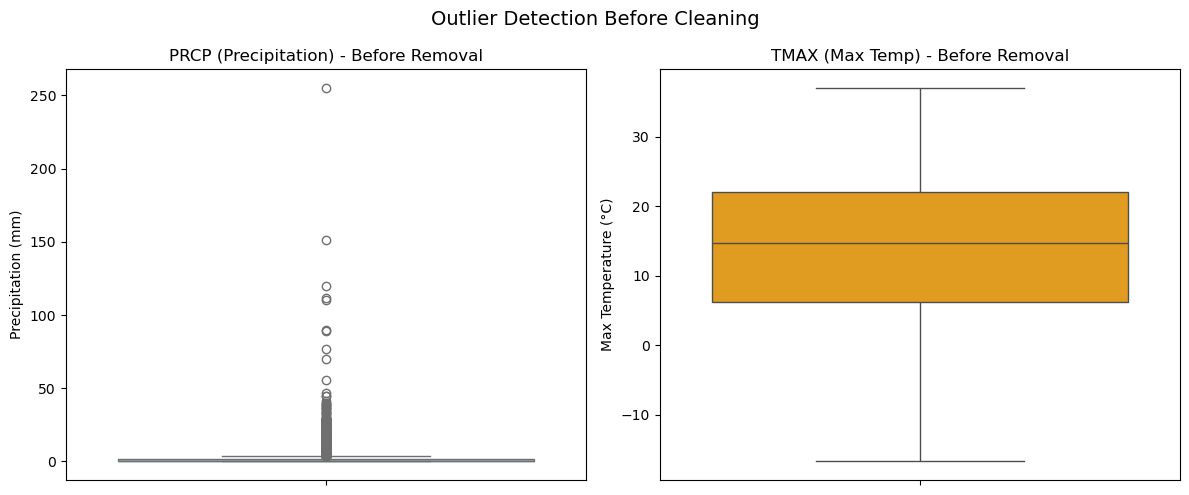

Saved: C:\Users\Asus\results\eda_visualizations\outliers_before.png


In [3]:
# Create boxplots for PRCP and TMAX before outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['PRCP'], ax=axes[0], color='skyblue')
axes[0].set_title('PRCP (Precipitation) - Before Removal')
axes[0].set_ylabel('Precipitation (mm)')

sns.boxplot(y=df['TMAX'], ax=axes[1], color='orange')
axes[1].set_title('TMAX (Max Temp) - Before Removal')
axes[1].set_ylabel('Max Temperature (°C)')

plt.suptitle('Outlier Detection Before Cleaning', fontsize=14)
plt.tight_layout()

# Save plot to results/eda_visualizations/
save_before = os.path.join(output_dir, 'outliers_before.png')
plt.savefig(save_before, dpi=300)
plt.show()

print(f"Saved: {save_before}")

In [4]:
def remove_outliers_iqr(data, columns):
    df_cleaned = data.copy()
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep rows inside IQR boundaries while retaining NaNs
        condition = ((df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)) | df_cleaned[col].isna()
        df_cleaned = df_cleaned[condition]
        
    return df_cleaned

# Remove extreme values from PRCP and TMAX as required
df_cleaned = remove_outliers_iqr(df, ['PRCP', 'TMAX'])

print(f"Original Row Count: {len(df)}")
print(f"Cleaned Row Count:  {len(df_cleaned)}")
print(f"Outliers Removed:   {len(df) - len(df_cleaned)}")

Original Row Count: 10954
Cleaned Row Count:  9644
Outliers Removed:   1310


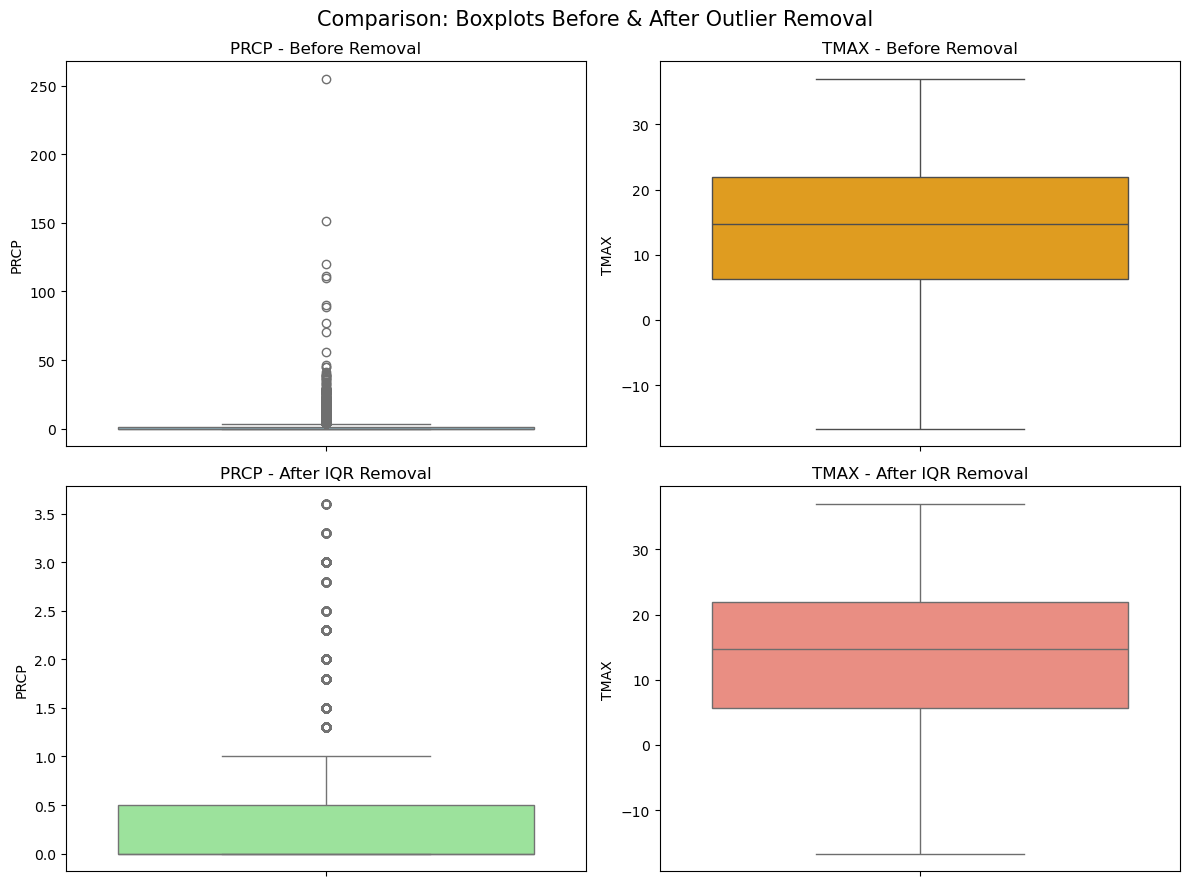

Saved: C:\Users\Asus\results\eda_visualizations\outliers_after.png


In [5]:
# Create side-by-side comparison boxplots (Before vs After)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Before Removal
sns.boxplot(y=df['PRCP'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('PRCP - Before Removal')

sns.boxplot(y=df['TMAX'], ax=axes[0, 1], color='orange')
axes[0, 1].set_title('TMAX - Before Removal')

# After Removal
sns.boxplot(y=df_cleaned['PRCP'], ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('PRCP - After IQR Removal')

sns.boxplot(y=df_cleaned['TMAX'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('TMAX - After IQR Removal')

plt.suptitle('Comparison: Boxplots Before & After Outlier Removal', fontsize=15)
plt.tight_layout()

# Save post-cleaning plot to results/eda_visualizations/
save_after = os.path.join(output_dir, 'outliers_after.png')
plt.savefig(save_after, dpi=300)
plt.show()

print(f"Saved: {save_after}")